# LAB 3 — Khám phá, đánh giá và diễn giải mẫu trong dữ liệu

**Môn học:** DBM302m  
**Sinh viên:** ................................  
**Mã sinh viên / Lớp:** ................................

Notebook này tập hợp **8 file Python của 4 phần 3.1–3.4 thành một bài lab chung**. Mỗi hoạt động có câu hỏi, giải thích, code, kết quả và hướng diễn giải. Báo cáo tổng hợp nằm cuối notebook và lấy số liệu trực tiếp từ kết quả chạy.

**Cách dùng:** đặt notebook cùng cấp với các thư mục `Lab 3.1`–`Lab 3.4`, mở bằng Jupyter hoặc VS Code, chọn kernel Python và **Restart Kernel → Run All**. Cell đầu kiểm tra và cài các thư viện còn thiếu nếu có kết nối Internet. Không cần chạy riêng các file `.py` hoặc `.R`.

Notebook dùng các CSV có sẵn. Khi tải từ GitHub, hãy tải cả thư mục `Lab3/`; riêng file notebook không chứa dữ liệu CSV. Kết quả bảng và hình được lưu trong notebook, đồng thời xuất vào `results_notebook/` khi chạy.

## 0. Luồng bài làm và nguồn code

**Dữ liệu → tiền xử lý → khai phá mẫu → đánh giá → diễn giải → báo cáo.**

| Thứ tự | Câu hỏi cần trả lời | Kết quả |
|---|---|---|
| 3.1 | Có những mẫu nào trong giỏ hàng, chuỗi và dữ liệu số? | Tập mặt hàng, luật kết hợp, mẫu tuần tự, các cụm |
| 3.2 | Mẫu vừa tìm có chất lượng như thế nào? | Luật sau lọc, chuỗi sau lọc, silhouette và WCSS |
| 3.3 | Khách hàng thường mua theo thứ tự nào? | Chuỗi sản phẩm phổ biến và support |
| 3.4 | Những cặp từ nào đáng chú ý trong review? | Cặp từ có PMI cao và đánh giá ý nghĩa |
| Báo cáo | Kết quả nói lên điều gì và dùng được ra sao? | Tổng hợp bằng chứng, ứng dụng và hạn chế |

**Quan hệ giữa các phần:** 3.2 dùng lại kết quả 3.1. Phần 3.3 dùng dữ liệu chuỗi sản phẩm riêng, còn 3.4 dùng văn bản. Chúng cùng minh họa quy trình khai phá dữ liệu, không phải bốn thuật toán nối đầu ra vào nhau.

| Code gốc | Vị trí trong notebook |
|---|---|
| `Lab 3.1/Lab 3_1_apriori.py` | 3.1A: Apriori và luật kết hợp |
| `Lab 3.1/Lab 3_1_prefixspan.py` | 3.1B: PrefixSpan trên chuỗi A–D |
| `Lab 3.1/Lab 3_1_kmeans.py` | 3.1C: K-Means |
| `Lab 3.2/Lab 3_2_RuleMining.py` | 3.2A: Đánh giá và lọc luật |
| `Lab 3.2/Lab 3_2_prefixspan.py` | 3.2B: Lọc mẫu tuần tự |
| `Lab 3.2/Lab 3_2_kmeans.py` | 3.2C: Silhouette và WCSS |
| `Lab 3.3/Lab 3_3_Sequential_Pattern_Mining.py` | 3.3: Chuỗi mua hàng |
| `Lab 3.4/Lab 3_4_MiningQualityPhrases.py` | 3.4: Tokenization và PMI |

Code được chia thành cell, đổi tên biến để tránh ghi đè và thay đường dẫn `__file__` bằng `Path`, vì notebook không có `__file__`. Các thuật toán và tham số mặc định của code mẫu được giữ. Bảng/hình, Jaccard, mẫu đóng và kiểm tra bigram là phần bổ sung, được ghi rõ. Code gốc và dữ liệu gốc không bị sửa. Các bộ dữ liệu của 3.1 và 3.2 được đối chiếu trước khi dùng chung.

Slide 3.1 chỉ yêu cầu chọn **một** kỹ thuật cho thực hành; notebook vẫn tích hợp cả ba để bạn theo dõi đầy đủ code đã được cung cấp.

In [1]:
# Chuẩn bị thư viện: chỉ cài gói còn thiếu, không cài lại mọi lần chạy.
import importlib.util
import subprocess
import sys

requirements = {
    'pandas': 'pandas>=2.0,<3',
    'numpy': 'numpy>=1.24,<3',
    'matplotlib': 'matplotlib>=3.7,<4',
    'sklearn': 'scikit-learn>=1.3,<2',
    'mlxtend': 'mlxtend==0.23.4',
    'prefixspan': 'prefixspan==0.5.2',
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Cài thư viện còn thiếu:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
print('Thư viện đã sẵn sàng.')

Thư viện đã sẵn sàng.


In [2]:
from pathlib import Path
from collections import Counter
import math
import re
import inspect
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from mlxtend.frequent_patterns import apriori, association_rules
from prefixspan import PrefixSpan
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
pd.set_option('display.max_colwidth', 110)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (8, 4.5), 'font.size': 11})

# Nếu Jupyter chạy ở thư mục khác, sửa DATA_ROOT thành thư mục chứa Lab 3.1–3.4.
DATA_ROOT = None
candidates = ([Path(DATA_ROOT)] if DATA_ROOT else
              [folder / suffix for folder in [Path.cwd(), *Path.cwd().parents]
               for suffix in ['', 'Lab3']])
LAB_ROOT = next((p.resolve() for p in candidates
                 if all((p / f'Lab 3.{i}').is_dir() for i in range(1, 5))), None)
if LAB_ROOT is None:
    raise FileNotFoundError('Không tìm thấy dữ liệu. Hãy đặt DATA_ROOT tới thư mục Lab3.')
OUTPUT_DIR = LAB_ROOT / 'results_notebook'
OUTPUT_DIR.mkdir(exist_ok=True)

PARAMS = {
    'apriori_min_support': 0.2,
    'rule_generation_min_lift': 1.0,
    'rule_filter_min_support': 0.1,
    'rule_filter_min_confidence': 0.5,
    'rule_filter_min_lift': 1.0,
    'sequence_min_count': 2,
    'sequence_max_length': 4,
    'customer_sequence_min_count': 2,
    'n_clusters': 3,
    'random_state': 0,
    'pmi_threshold': 1.0,
    'bigram_min_review_count': 1,
}

def itemset_text(items):
    return ', '.join(sorted(items))

def rule_table(frame):
    result = frame.copy()
    result['antecedents'] = result['antecedents'].map(itemset_text)
    result['consequents'] = result['consequents'].map(itemset_text)
    return result

def sequence_table(patterns, total):
    return pd.DataFrame([
        {'Pattern': ' → '.join(pattern), 'Support Count': count,
         'Support': count / total, 'Length': len(pattern)}
        for count, pattern in patterns
    ], columns=['Pattern', 'Support Count', 'Support', 'Length']).sort_values(
        ['Support Count', 'Length', 'Pattern'], ascending=[False, False, True]
    ).reset_index(drop=True)

def show_metrics(frame, columns):
    display(frame[columns].style.format({
        c: '{:.4f}' for c in columns
        if c in ['support', 'confidence', 'lift', 'jaccard', 'Support', 'PMI']
    }))

def markdown_table(frame):
    # Không cần cài thêm tabulate để tạo báo cáo Markdown.
    def cell(value):
        return str(value).replace('|', r'\|').replace('\n', ' ')
    lines = ['| ' + ' | '.join(map(cell, frame.columns)) + ' |',
             '| ' + ' | '.join(['---'] * len(frame.columns)) + ' |']
    lines += ['| ' + ' | '.join(cell(v) for v in row) + ' |'
              for row in frame.itertuples(index=False, name=None)]
    return '\n'.join(lines)

versions = pd.DataFrame([
    {'Library': name, 'Version': importlib.metadata.version(name)}
    for name in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'mlxtend', 'prefixspan']
])
display(versions)
display(pd.DataFrame(PARAMS.items(), columns=['Parameter', 'Value']))
print('Đã tìm thấy đủ 4 thư mục dữ liệu. Kết quả sẽ lưu trong results_notebook/.')

,Library,Version
0,pandas,2.3.3
1,numpy,2.2.1
2,matplotlib,3.10.6
3,scikit-learn,1.7.2
4,mlxtend,0.23.4
5,prefixspan,0.5.2


,Parameter,Value
0,apriori_min_support,0.2
1,rule_generation_min_lift,1.0
2,rule_filter_min_support,0.1
3,rule_filter_min_confidence,0.5
4,rule_filter_min_lift,1.0
5,sequence_min_count,2.0
6,sequence_max_length,4.0
7,customer_sequence_min_count,2.0
8,n_clusters,3.0
9,random_state,0.0


Đã tìm thấy đủ 4 thư mục dữ liệu. Kết quả sẽ lưu trong results_notebook/.


### 0.1. Khảo sát dữ liệu trước khi chạy thuật toán

Đơn vị quan sát khác nhau giữa các bộ dữ liệu: **một giỏ hàng**, **một chuỗi**, **một điểm dữ liệu số**, hoặc **một review**. Support chỉ có ý nghĩa khi xác định đúng mẫu số.

Code gốc dùng `dropna()`. Ở đây vẫn loại dòng thiếu ở các cột cần phân tích, đồng thời ghi số dòng bị loại. Không tự loại giao dịch giống nhau vì chúng có thể là những lần mua khác nhau.

In [3]:
FILES = {
    'grocery': ('Lab 3.1/example_grocery_transaction_dataset.csv', ['TransactionID', 'Items']),
    'actions': ('Lab 3.1/example_sequenceid_dataset.csv', ['SequenceID', 'Actions']),
    'features': ('Lab 3.1/example_features_dataset.csv', ['Feature1', 'Feature2']),
    'customers': ('Lab 3.3/customer_transactions_dataset.csv', ['TransactionID', 'Sequence']),
    'reviews': ('Lab 3.4/product_reviews.csv', ['ReviewID', 'ReviewText']),
}
raw_data, clean_data, audit_rows = {}, {}, []
for name, (relative_path, required_columns) in FILES.items():
    raw = pd.read_csv(LAB_ROOT / relative_path)
    if not set(required_columns).issubset(raw.columns):
        raise ValueError(f'{relative_path}: thiếu cột bắt buộc {required_columns}')
    cleaned = raw.dropna(subset=required_columns).copy()
    text_columns = [c for c in ['Items', 'Actions', 'Sequence', 'ReviewText']
                    if c in cleaned.columns]
    for column in text_columns:
        cleaned[column] = cleaned[column].astype(str).str.strip()
        cleaned = cleaned.loc[cleaned[column].ne('')].copy()
    if name == 'features':
        cleaned[required_columns] = cleaned[required_columns].apply(pd.to_numeric, errors='coerce')
        cleaned = cleaned.dropna(subset=required_columns)
        if not np.isfinite(cleaned[required_columns].to_numpy()).all():
            raise ValueError('Dữ liệu số chứa giá trị vô hạn.')
    if cleaned.empty:
        raise ValueError(f'{relative_path}: không có dữ liệu hợp lệ.')
    raw_data[name], clean_data[name] = raw, cleaned
    audit_rows.append({'Dataset': name, 'File': relative_path, 'Raw Rows': len(raw),
                       'Valid Rows': len(cleaned), 'Removed Rows': len(raw) - len(cleaned)})
data_audit = pd.DataFrame(audit_rows)
display(data_audit)

# 3.2 cung cấp bản sao của ba bộ dữ liệu 3.1. Xác nhận trước khi tái sử dụng kết quả.
for name in ['grocery', 'actions', 'features']:
    counterpart = LAB_ROOT / 'Lab 3.2' / Path(FILES[name][0]).name
    pd.testing.assert_frame_equal(raw_data[name], pd.read_csv(counterpart))
print('Dữ liệu 3.1 và 3.2 giống nhau: phần 3.2 có thể dùng lại kết quả 3.1.')

for name in FILES:
    display(Markdown(f'**Dữ liệu mẫu: {name}**'))
    display(clean_data[name].head(3))

,Dataset,File,Raw Rows,Valid Rows,Removed Rows
0,grocery,Lab 3.1/example_grocery_transaction_dataset.csv,10,10,0
1,actions,Lab 3.1/example_sequenceid_dataset.csv,10,10,0
2,features,Lab 3.1/example_features_dataset.csv,9,9,0
3,customers,Lab 3.3/customer_transactions_dataset.csv,10,10,0
4,reviews,Lab 3.4/product_reviews.csv,6,6,0


Dữ liệu 3.1 và 3.2 giống nhau: phần 3.2 có thể dùng lại kết quả 3.1.


**Dữ liệu mẫu: grocery**

,TransactionID,Items
0,1,"Apple, Banana, Cereal"
1,2,"Apple, Banana, Milk"
2,3,"Apple, Banana, Cereal, Milk"


**Dữ liệu mẫu: actions**

...

,Feature1,Feature2
0,2.5,3.0
1,3.0,3.5
2,2.8,2.9


**Dữ liệu mẫu: customers**

,TransactionID,Sequence
0,1,"Apple, Banana, Cereal, Donut"
1,2,"Apple, Cereal, Donut"
2,3,"Banana, Donut"


**Dữ liệu mẫu: reviews**

,ReviewID,ReviewText
0,1,The product is excellent and very reliable.
1,2,This is a terrible product; don't buy it.
2,3,I am happy with this purchase; it's worth the price.


## 1. Lab 3.1 — Khám phá mẫu

Pattern discovery giúp phát hiện cấu trúc lặp lại để hỗ trợ quyết định. Có ba hướng trong code được cung cấp:

- **Apriori:** tìm các mặt hàng cùng xuất hiện, ứng dụng trong phân tích giỏ hàng và gợi ý mua kèm.
- **PrefixSpan:** tìm các hành động xuất hiện theo thứ tự, ứng dụng trong hành trình người dùng hoặc chuỗi mua hàng.
- **K-Means:** gom các điểm dữ liệu gần nhau, ứng dụng trong phân nhóm khi chưa có nhãn.

### 1A. Apriori: các mặt hàng nào thường xuất hiện cùng nhau?

**Nguồn:** `Lab 3.1/Lab 3_1_apriori.py`.

**Đầu vào:** mỗi dòng là một giỏ hàng, cột `Items` chứa các mặt hàng ngăn bằng dấu phẩy.  
**Tiền xử lý:** tách và bỏ khoảng trắng ở đầu/cuối tên hàng, chuyển thành bảng one-hot dạng Boolean. Không xóa khoảng trắng bên trong tên hàng.  
**Đầu ra:** frequent itemsets và association rules.

Apriori không xét thứ tự các mặt hàng. Với ngưỡng support 0.2, một tập mặt hàng phải xuất hiện trong ít nhất 20% giỏ hàng để được giữ lại.

In [4]:
grocery = clean_data['grocery'].copy()
baskets = grocery['Items'].map(lambda row: [item.strip() for item in row.split(',') if item.strip()])
all_items = sorted({item for basket in baskets for item in basket})
onehot_df = pd.DataFrame([{item: item in basket for item in all_items}
                         for basket in baskets], dtype=bool)
display(onehot_df)

frequent_itemsets = apriori(onehot_df,
                           min_support=PARAMS['apriori_min_support'], use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
itemset_display = frequent_itemsets.copy()
itemset_display['itemsets'] = itemset_display['itemsets'].map(itemset_text)
itemset_display['Support Count'] = np.rint(itemset_display['support'] * len(grocery)).astype(int)
show_metrics(itemset_display, ['itemsets', 'Support Count', 'support'])
print(f'Tìm được {len(frequent_itemsets)} tập mặt hàng phổ biến trên {len(grocery)} giỏ hàng.')

,Apple,Banana,Cereal,Milk
0,True,True,True,False
1,True,True,False,True
2,True,True,True,True
3,True,False,False,True
4,True,False,True,False
5,False,True,True,False
6,False,True,False,True
7,True,True,False,False
8,True,True,True,True
9,True,True,True,False


,itemsets,Support Count,support
0,Apple,8,0.8000
1,Banana,8,0.8000
2,Cereal,6,0.6000
3,"Apple, Banana",6,0.6000
4,Milk,5,0.5000
5,"Apple, Cereal",5,0.5000
6,"Banana, Cereal",5,0.5000
7,"Apple, Milk",4,0.4000
8,"Banana, Milk",4,0.4000
9,"Apple, Banana, Cereal",4,0.4000


Tìm được 15 tập mặt hàng phổ biến trên 10 giỏ hàng.


### 1A.1. Từ tập mặt hàng phổ biến sang luật kết hợp

Luật `A → B` được đọc là: trong các giỏ có tập mặt hàng A, B cũng thường xuất hiện. A và B có thể chứa nhiều mặt hàng. Mũi tên ở đây **không có nghĩa là mua A trước B** và không chứng minh A gây ra B.

Code gốc tạo luật với `lift ≥ 1.0`. Vì vậy bảng đầu tiên đã có bộ lọc lift; phần 3.2 tiếp tục đánh giá, không xem bảng này là tất cả luật có thể có.

,antecedents,consequents,support,confidence,lift
0,Cereal,Apple,0.5000,0.8333,1.0417
1,Cereal,Banana,0.5000,0.8333,1.0417
2,Apple,Cereal,0.5000,0.6250,1.0417
3,Banana,Cereal,0.5000,0.6250,1.0417
4,"Apple, Banana",Cereal,0.4000,0.6667,1.1111
5,Cereal,"Apple, Banana",0.4000,0.6667,1.1111
6,Milk,Apple,0.4000,0.8000,1.0000
7,Milk,Banana,0.4000,0.8000,1.0000
8,"Apple, Cereal",Banana,0.4000,0.8000,1.0000
9,"Banana, Cereal",Apple,0.4000,0.8000,1.0000


Số luật vượt ngưỡng lift ban đầu: 34.


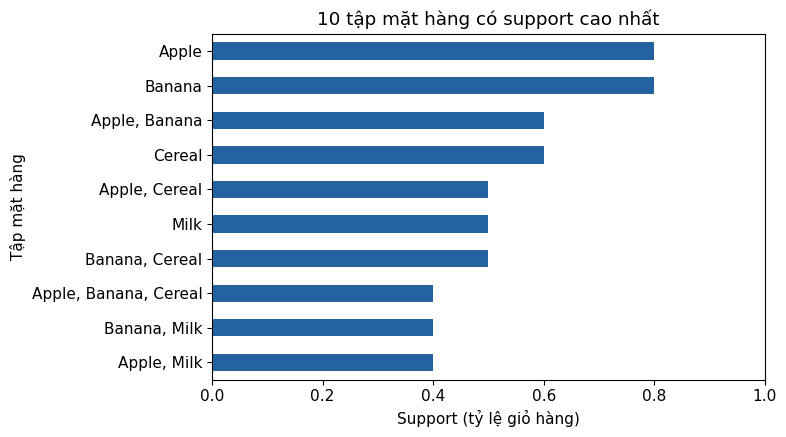

In [5]:
if not (frequent_itemsets['itemsets'].map(len) >= 2).any():
    raise ValueError('Không có tập ít nhất 2 mặt hàng; hãy kiểm tra dữ liệu hoặc giảm min_support.')
rule_kwargs = {'metric': 'lift', 'min_threshold': PARAMS['rule_generation_min_lift']}
# Một số phiên bản mlxtend nhận thêm số giao dịch.
if 'num_itemsets' in inspect.signature(association_rules).parameters:
    rule_kwargs['num_itemsets'] = len(grocery)
rules = association_rules(frequent_itemsets, **rule_kwargs)
rules = rules.sort_values(['support', 'lift', 'confidence'], ascending=False).reset_index(drop=True)
rule_columns = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
show_metrics(rule_table(rules), rule_columns)
print(f'Số luật vượt ngưỡng lift ban đầu: {len(rules)}.')

fig, ax = plt.subplots()
itemset_display.head(10).sort_values('support').plot.barh(
    x='itemsets', y='support', legend=False, ax=ax, color='#2463a0')
ax.set(xlabel='Support (tỷ lệ giỏ hàng)', ylabel='Tập mặt hàng',
       title='10 tập mặt hàng có support cao nhất', xlim=(0, 1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '01_frequent_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()

**Cách nhận xét:** đọc số lần xuất hiện trước, rồi xem confidence và lift ở phần 3.2. Một mặt hàng phổ biến chưa chắc tạo thành một luật có liên hệ mạnh. Gợi ý mua kèm chỉ là ứng dụng tiềm năng, chưa có thử nghiệm kinh doanh để xác nhận hiệu quả.

### 1B. PrefixSpan: mẫu nào lặp lại theo thứ tự?

**Nguồn:** `Lab 3.1/Lab 3_1_prefixspan.py`.

Mỗi dòng `Actions` là một chuỗi A–D. PrefixSpan tìm **subsequence**: các ký hiệu phải giữ đúng thứ tự, nhưng không nhất thiết liền nhau. Ví dụ `A → D` có mặt trong `A → B → C → D`.

`frequent(2)` sử dụng **số chuỗi**, không phải tỷ lệ 2%. Một mẫu xuất hiện nhiều lần trong một chuỗi vẫn chỉ đóng góp một đơn vị support của chuỗi đó.

In [6]:
actions = clean_data['actions'].copy()
action_sequences = [[a.strip() for a in row.split(',') if a.strip()]
                    for row in actions['Actions']]
ps_actions = PrefixSpan(action_sequences)
action_patterns = ps_actions.frequent(PARAMS['sequence_min_count'])
action_pattern_df = sequence_table(action_patterns, len(action_sequences))
show_metrics(action_pattern_df, ['Pattern', 'Support Count', 'Support', 'Length'])
print(f'{len(action_sequences)} chuỗi đầu vào, {len(action_patterns)} mẫu tuần tự phổ biến.')

,Pattern,Support Count,Support,Length
0,A,7,0.7000,1
1,D,7,0.7000,1
2,B,6,0.6000,1
3,C,6,0.6000,1
4,A → D,5,0.5000,2
5,A → B,4,0.4000,2
6,A → C,4,0.4000,2
7,C → D,4,0.4000,2
8,A → C → D,3,0.3000,3
9,B → C,3,0.3000,2


10 chuỗi đầu vào, 13 mẫu tuần tự phổ biến.


### 1C. K-Means: dữ liệu số hình thành những nhóm nào?

**Nguồn:** `Lab 3.1/Lab 3_1_kmeans.py`.

Hai cột `Feature1`, `Feature2` là dữ liệu số. K-Means chia các điểm thành `k = 3` cụm bằng cách giảm tổng bình phương khoảng cách tới tâm cụm. `random_state = 0`, `n_init = 10` giữ kết quả có thể tái lập.

Hai đặc trưng mẫu có thang đo gần nhau nên giữ cách dùng dữ liệu trực tiếp như code gốc. Với dữ liệu có thang đo chênh lệch lớn, cần cân nhắc chuẩn hóa trước khi tính khoảng cách.

Nhãn cụm 0, 1, 2 chỉ là mã nhóm, không phải thứ hạng. Dữ liệu chỉ có tên Feature1/Feature2 nên không thể tự gán ý nghĩa như “khách hàng VIP” cho từng cụm.

,Feature1,Feature2,Cluster
0,2.5,3.0,2
1,3.0,3.5,2
2,2.8,2.9,2
3,5.5,6.0,0
4,6.0,5.9,0
5,5.8,5.7,0
6,9.2,9.5,1
7,9.5,9.8,1
8,9.8,9.6,1


,Feature1,Feature2
Cluster,,
0,5.766667,5.866667
1,9.500000,9.633333
2,2.766667,3.133333


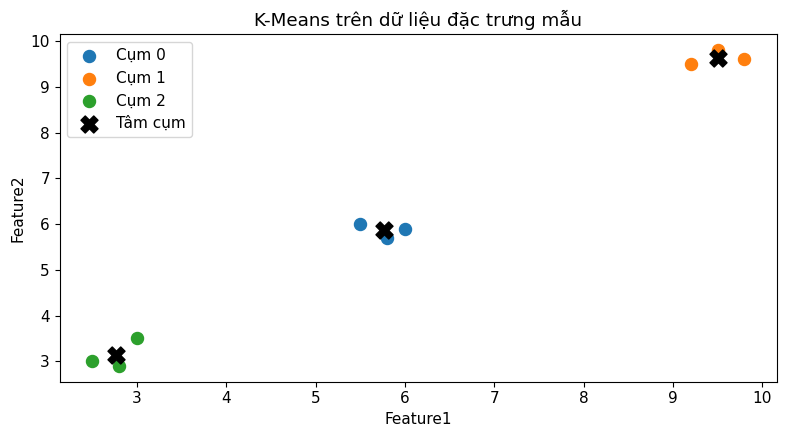

In [7]:
features = clean_data['features'].copy()
feature_data = features[['Feature1', 'Feature2']]
if not 2 <= PARAMS['n_clusters'] < len(feature_data):
    raise ValueError('Chọn 2 ≤ k < số điểm để có thể đánh giá silhouette.')
if PARAMS['n_clusters'] > len(feature_data.drop_duplicates()):
    raise ValueError('Số cụm vượt số điểm phân biệt.')
kmeans = KMeans(n_clusters=PARAMS['n_clusters'], n_init=10,
                random_state=PARAMS['random_state'])
features['Cluster'] = kmeans.fit_predict(feature_data)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Feature1', 'Feature2'])
centers.index.name = 'Cluster'
display(features)
display(centers)

fig, ax = plt.subplots()
for cluster_id, group in features.groupby('Cluster'):
    ax.scatter(group['Feature1'], group['Feature2'], s=75, label=f'Cụm {cluster_id}')
ax.scatter(centers['Feature1'], centers['Feature2'], c='black', marker='X', s=150, label='Tâm cụm')
ax.set(xlabel='Feature1', ylabel='Feature2', title='K-Means trên dữ liệu đặc trưng mẫu')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Lab 3.2 — Đánh giá mẫu đã khám phá

Tìm được nhiều mẫu chưa đủ. Cần xem mẫu có thường gặp, có liên hệ mạnh, hoặc có tạo ra các nhóm tách biệt không. Phần này dùng lại kết quả 3.1 thay vì đọc cùng dữ liệu và chạy lại toàn bộ thuật toán.

### 2A. Đánh giá luật kết hợp

**Nguồn:** `Lab 3.2/Lab 3_2_RuleMining.py`.

Với luật $A \to B$:

| Chỉ số | Công thức | Cách hiểu |
|---|---|---|
| Support | $P(A \cap B)$ | Tỷ lệ giỏ chứa đồng thời cả A và B |
| Confidence | $P(A \cap B)/P(A)$ | Tỷ lệ giỏ có B trong các giỏ có A |
| Lift | $P(A \cap B)/(P(A)P(B))$ | Liên hệ so với mức kỳ vọng nếu A và B độc lập |
| Jaccard *(bổ sung)* | $P(A \cap B)/(P(A)+P(B)-P(A \cap B))$ | Mức giao nhau giữa tập giỏ có A và tập giỏ có B |

Lift > 1 thể hiện liên hệ dương; lift = 1 tương ứng độc lập theo tần suất quan sát; lift < 1 thể hiện liên hệ âm. Lift cao vẫn có thể dựa trên rất ít giao dịch.

Slide cũng nhắc **F1-score**: $2PR/(P+R)$, với P là precision và R là recall. Muốn đánh giá F1 cần định nghĩa nhãn đúng và dự đoán tương ứng. Bài mẫu không có bài toán dự đoán với nhãn thật, nên không gán confidence thành F1.

In [8]:
# Jaccard là phần bổ sung để minh họa metric trong slide.
rules['jaccard'] = rules['support'] / (
    rules['antecedent support'] + rules['consequent support'] - rules['support'])
filtered_rules = rules.loc[
    (rules['support'] >= PARAMS['rule_filter_min_support']) &
    (rules['confidence'] >= PARAMS['rule_filter_min_confidence']) &
    (rules['lift'] >= PARAMS['rule_filter_min_lift'])
].copy()
filtered_rules = filtered_rules.sort_values(
    ['support', 'lift', 'confidence'], ascending=False).reset_index(drop=True)
show_metrics(rule_table(filtered_rules), rule_columns + ['jaccard'])
print(f'Luật trước lọc: {len(rules)}; sau lọc: {len(filtered_rules)}.')
if PARAMS['rule_filter_min_support'] < PARAMS['apriori_min_support']:
    print('Ngưỡng lọc support thấp hơn ngưỡng khai phá: không khôi phục được mẫu đã bị Apriori loại.')

if not filtered_rules.empty:
    selected_rule = filtered_rules.iloc[0]
    antecedent_mask = onehot_df[list(selected_rule['antecedents'])].all(axis=1)
    consequent_mask = onehot_df[list(selected_rule['consequents'])].all(axis=1)
    n_a = int(antecedent_mask.sum())
    n_b = int(consequent_mask.sum())
    n_ab = int((antecedent_mask & consequent_mask).sum())
    display(Markdown(
        f"**Đọc một luật từ dữ liệu thật:** {itemset_text(selected_rule['antecedents'])} → "
        f"{itemset_text(selected_rule['consequents'])}.\n\n"
        f"Có A: {n_a} giỏ; có B: {n_b} giỏ; có cả A và B: {n_ab}/{len(grocery)} giỏ. "
        f"Support = {n_ab}/{len(grocery)} = **{selected_rule['support']:.1%}**; "
        f"confidence = {n_ab}/{n_a} = **{selected_rule['confidence']:.1%}**; "
        f"lift = **{selected_rule['lift']:.3f}**. "
        'Luật được chọn theo support giảm dần, rồi lift và confidence; đây là tiêu chí trình bày, '
        'không khẳng định là luật tốt nhất cho mọi mục tiêu kinh doanh.'
    ))
else:
    display(Markdown('Không có luật đạt bộ ngưỡng hiện tại. Đây cũng là một kết quả cần báo cáo.'))

,antecedents,consequents,support,confidence,lift,jaccard
0,Cereal,Apple,0.5000,0.8333,1.0417,0.5556
1,Cereal,Banana,0.5000,0.8333,1.0417,0.5556
2,Apple,Cereal,0.5000,0.6250,1.0417,0.5556
3,Banana,Cereal,0.5000,0.6250,1.0417,0.5556
4,"Apple, Banana",Cereal,0.4000,0.6667,1.1111,0.5000
5,Cereal,"Apple, Banana",0.4000,0.6667,1.1111,0.5000
6,Milk,Apple,0.4000,0.8000,1.0000,0.4444
7,Milk,Banana,0.4000,0.8000,1.0000,0.4444
8,"Apple, Cereal",Banana,0.4000,0.8000,1.0000,0.4444
9,"Banana, Cereal",Apple,0.4000,0.8000,1.0000,0.4444


Luật trước lọc: 34; sau lọc: 25.
Ngưỡng lọc support thấp hơn ngưỡng khai phá: không khôi phục được mẫu đã bị Apriori loại.


**Đọc một luật từ dữ liệu thật:** Cereal → Apple.

Có A: 6 giỏ; có B: 8 giỏ; có cả A và B: 5/10 giỏ. Support = 5/10 = **50.0%**; confidence = 5/6 = **83.3%**; lift = **1.042**. Luật được chọn theo support giảm dần, rồi lift và confidence; đây là tiêu chí trình bày, không khẳng định là luật tốt nhất cho mọi mục tiêu kinh doanh.

### 2B. Đánh giá mẫu tuần tự

**Nguồn:** `Lab 3.2/Lab 3_2_prefixspan.py`.

Giữ các mẫu có support count ≥ 2 và độ dài ≤ 4 như code gốc. Đây là lọc theo tần suất và độ dài; chưa phải kiểm định ý nghĩa thống kê.

Nếu mọi mẫu đã thỏa hai điều kiện, số lượng trước và sau sẽ bằng nhau. Không cần thay ngưỡng chỉ để tạo ra khác biệt.

In [9]:
filtered_action_patterns = [
    (count, pattern) for count, pattern in action_patterns
    if count >= PARAMS['sequence_min_count'] and len(pattern) <= PARAMS['sequence_max_length']
]
filtered_action_df = sequence_table(filtered_action_patterns, len(action_sequences))
show_metrics(filtered_action_df, ['Pattern', 'Support Count', 'Support', 'Length'])
print(f'Mẫu trước lọc: {len(action_patterns)}; sau lọc: {len(filtered_action_patterns)}.')
display(Markdown('**Đọc kết quả:** dùng mẫu dài ít nhất hai ký hiệu để diễn giải hành trình. '
                 'Mẫu một ký hiệu chỉ thể hiện tần suất xuất hiện của ký hiệu đó.'))

,Pattern,Support Count,Support,Length
0,A,7,0.7000,1
1,D,7,0.7000,1
2,B,6,0.6000,1
3,C,6,0.6000,1
4,A → D,5,0.5000,2
5,A → B,4,0.4000,2
6,A → C,4,0.4000,2
7,C → D,4,0.4000,2
8,A → C → D,3,0.3000,3
9,B → C,3,0.3000,2


Mẫu trước lọc: 13; sau lọc: 13.


**Đọc kết quả:** dùng mẫu dài ít nhất hai ký hiệu để diễn giải hành trình. Mẫu một ký hiệu chỉ thể hiện tần suất xuất hiện của ký hiệu đó.

### 2C. Đánh giá các cụm K-Means

**Nguồn:** `Lab 3.2/Lab 3_2_kmeans.py`.

- **Silhouette** nằm trong [-1, 1]. Điểm gần 1 cho thấy các điểm gần cụm của mình và xa cụm khác; gần 0 thể hiện vùng chồng lấn; âm có thể gợi ý phân cụm chưa phù hợp.
- **WCSS** là tổng bình phương khoảng cách tới tâm cụm. WCSS thường giảm khi tăng k, nên không chọn k chỉ vì WCSS nhỏ nhất. Biểu đồ elbow giúp tìm mức giảm bắt đầu chậm lại.

Notebook khảo sát k từ 1 tới tối đa 10 hoặc số điểm phân biệt. Silhouette chỉ tính khi có từ 2 tới n−1 cụm thực tế. Giá trị cao trên 9 điểm mẫu chưa chứng minh mô hình sẽ tốt trên dữ liệu lớn.

,Number of Points
Cluster,
0,3
1,3
2,3


Silhouette với k=3: 0.8914


,k,WCSS,Silhouette
0,1,132.9178,NaN
1,2,25.4400,0.7206
2,3,0.7333,0.8914
3,4,0.4500,0.7172
4,5,0.2883,0.4751
5,6,0.1550,0.2654
6,7,0.0900,0.2035
7,8,0.0400,0.0865
8,9,0.0000,NaN


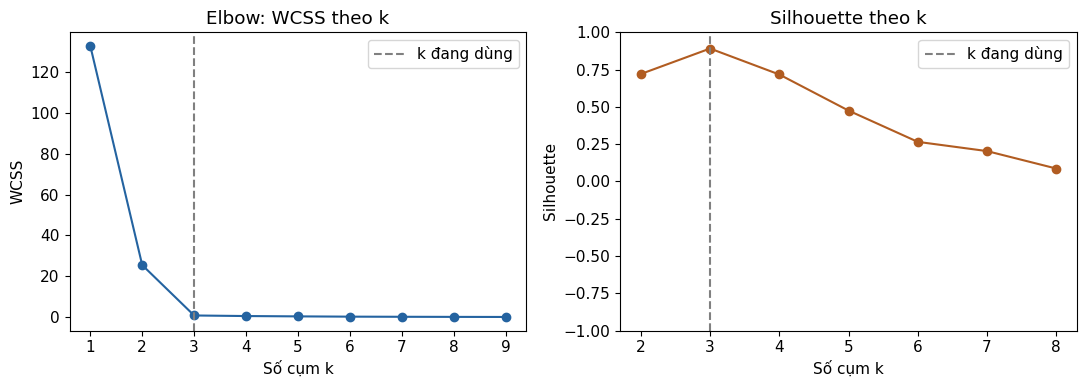

In [10]:
silhouette_avg = silhouette_score(feature_data, features['Cluster'])
cluster_sizes = features.groupby('Cluster').size().rename('Number of Points').to_frame()
display(cluster_sizes)
print(f'Silhouette với k={PARAMS["n_clusters"]}: {silhouette_avg:.4f}')

max_k = min(10, len(feature_data.drop_duplicates()))
k_rows = []
for k in range(1, max_k + 1):
    model = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10,
                   random_state=PARAMS['random_state']).fit(feature_data)
    labels = model.labels_
    score = (silhouette_score(feature_data, labels)
             if 2 <= len(set(labels)) < len(feature_data) else np.nan)
    k_rows.append({'k': k, 'WCSS': model.inertia_, 'Silhouette': score})
k_evaluation = pd.DataFrame(k_rows)
display(k_evaluation.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_evaluation['k'], k_evaluation['WCSS'], marker='o', color='#2463a0')
axes[0].set(xlabel='Số cụm k', ylabel='WCSS', title='Elbow: WCSS theo k')
valid_k = k_evaluation.dropna(subset=['Silhouette'])
axes[1].plot(valid_k['k'], valid_k['Silhouette'], marker='o', color='#b15c21')
axes[1].set(xlabel='Số cụm k', ylabel='Silhouette', title='Silhouette theo k', ylim=(-1, 1))
for ax in axes:
    ax.axvline(PARAMS['n_clusters'], linestyle='--', color='gray', label='k đang dùng')
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '03_cluster_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Lab 3.3 — Khai phá chuỗi mua hàng

**Nguồn:** `Lab 3.3/Lab 3_3_Sequential_Pattern_Mining.py`.

Ở 3.1B, A–D chỉ là ký hiệu minh họa. Phần này dùng tên sản phẩm để dễ diễn giải hành vi mua hàng. Mỗi dòng `Sequence` được xem là một chuỗi theo đúng thứ tự đã cung cấp; CSV không có timestamp nên không suy ra khoảng thời gian giữa hai lần mua.

**Luồng code:** tách chuỗi → mã hóa tên mặt hàng thành số nguyên → PrefixSpan → giải mã → bảng Pattern/Support/Pattern Length → xuất CSV.

Mã hóa số nguyên giữ nguyên ý nghĩa và thứ tự sản phẩm, không tạo ra thứ hạng cho sản phẩm.

**Hai loại mẫu cần hiểu:**

- *Frequent sequential pattern:* mẫu có support đạt ngưỡng.
- *Closed sequential pattern:* mẫu phổ biến không có mẫu dài hơn chứa nó mà có cùng support. Mẫu đóng giúp giảm kết quả dư thừa; không đồng nghĩa với mẫu dài nhất hay maximal pattern.

Ứng dụng có thể là gợi ý sản phẩm tiếp theo hoặc phân tích đường đi trên website, nhưng subsequence không đảm bảo một hành động xảy ra ngay sau hành động khác.

In [11]:
customer_data = clean_data['customers'].copy()
customer_sequences = [[item.strip() for item in row.split(',') if item.strip()]
                      for row in customer_data['Sequence']]
item_labels = sorted({item for sequence in customer_sequences for item in sequence})
item_to_int = {item: i for i, item in enumerate(item_labels)}
sequences_int = [[item_to_int[item] for item in sequence] for sequence in customer_sequences]
display(pd.DataFrame(item_to_int.items(), columns=['Item', 'Integer ID']))

ps_customers = PrefixSpan(sequences_int)
customer_patterns_int = ps_customers.frequent(PARAMS['customer_sequence_min_count'])
customer_patterns = [(count, [item_labels[i] for i in pattern])
                     for count, pattern in customer_patterns_int]
customer_pattern_df = sequence_table(customer_patterns, len(customer_sequences))
show_metrics(customer_pattern_df, ['Pattern', 'Support Count', 'Support', 'Length'])

# Giữ tên cột đầu ra của script gốc, nhưng xuất vào thư mục kết quả riêng.
customer_export = customer_pattern_df[['Pattern', 'Support Count', 'Length']].rename(
    columns={'Support Count': 'Support', 'Length': 'Pattern Length'})
customer_export['Pattern'] = customer_export['Pattern'].str.replace(' → ', ' -> ', regex=False)
customer_export.to_csv(OUTPUT_DIR / 'frequent_patterns.csv', index=False, encoding='utf-8-sig')
print(f'Tìm được {len(customer_pattern_df)} mẫu; đã xuất results_notebook/frequent_patterns.csv.')

,Item,Integer ID
0,Apple,0
1,Banana,1
2,Cereal,2
3,Donut,3


,Pattern,Support Count,Support,Length
0,Apple,7,0.7000,1
1,Donut,7,0.7000,1
2,Banana,6,0.6000,1
3,Cereal,6,0.6000,1
4,Apple → Donut,5,0.5000,2
5,Apple → Banana,4,0.4000,2
6,Apple → Cereal,4,0.4000,2
7,Cereal → Donut,4,0.4000,2
8,Apple → Cereal → Donut,3,0.3000,3
9,Banana → Cereal,3,0.3000,2


Tìm được 13 mẫu; đã xuất results_notebook/frequent_patterns.csv.


### 3.1. Đọc mẫu và so sánh frequent với closed

Phần bổ sung dưới đây kiểm tra mẫu đóng trên danh sách mẫu phổ biến đã khai phá. Cách so sánh từng cặp phù hợp với dữ liệu mẫu nhỏ; với dữ liệu lớn nên dùng thuật toán khai phá closed patterns chuyên dụng.

,Pattern,Support Count,Support,Length
0,Apple,7,0.7000,1
1,Donut,7,0.7000,1
2,Banana,6,0.6000,1
3,Cereal,6,0.6000,1
4,Apple → Donut,5,0.5000,2
5,Apple → Banana,4,0.4000,2
6,Apple → Cereal,4,0.4000,2
7,Cereal → Donut,4,0.4000,2
8,Apple → Cereal → Donut,3,0.3000,3
9,Banana → Cereal,3,0.3000,2


Frequent patterns: 13; closed patterns: 13.


**Mẫu cần diễn giải:** `Apple → Donut` xuất hiện trong **5/10 chuỗi (50%)**. Các mặt hàng giữ đúng thứ tự nhưng có thể có mặt hàng khác xen giữa. Đây là cơ sở để đề xuất gợi ý theo hành trình; chưa phải xác suất mua ngay bước tiếp theo.

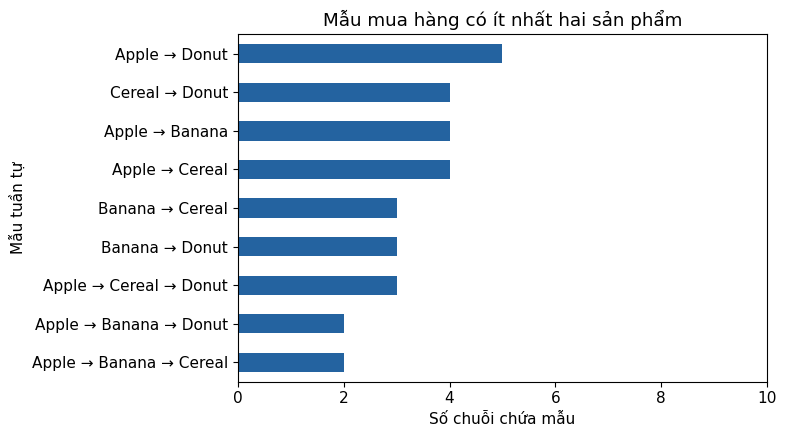

In [12]:
def is_subsequence(shorter, longer):
    iterator = iter(longer)
    return all(any(candidate == item for candidate in iterator) for item in shorter)

closed_customer_patterns = [
    (count, pattern) for count, pattern in customer_patterns
    if not any(other_count == count and len(other_pattern) > len(pattern)
               and is_subsequence(pattern, other_pattern)
               for other_count, other_pattern in customer_patterns)
]
closed_customer_df = sequence_table(closed_customer_patterns, len(customer_sequences))
show_metrics(closed_customer_df, ['Pattern', 'Support Count', 'Support', 'Length'])
print(f'Frequent patterns: {len(customer_patterns)}; closed patterns: {len(closed_customer_patterns)}.')

multi_customer = customer_pattern_df.loc[customer_pattern_df['Length'] >= 2].copy()
if not multi_customer.empty:
    leading_sequence = multi_customer.iloc[0]
    display(Markdown(
        f"**Mẫu cần diễn giải:** `{leading_sequence['Pattern']}` xuất hiện trong "
        f"**{int(leading_sequence['Support Count'])}/{len(customer_sequences)} chuỗi "
        f"({leading_sequence['Support']:.0%})**. "
        'Các mặt hàng giữ đúng thứ tự nhưng có thể có mặt hàng khác xen giữa. '
        'Đây là cơ sở để đề xuất gợi ý theo hành trình; chưa phải xác suất mua ngay bước tiếp theo.'
    ))
    fig, ax = plt.subplots()
    multi_customer.head(10).sort_values('Support Count').plot.barh(
        x='Pattern', y='Support Count', ax=ax, legend=False, color='#2463a0')
    ax.set(xlabel='Số chuỗi chứa mẫu', ylabel='Mẫu tuần tự',
           title='Mẫu mua hàng có ít nhất hai sản phẩm')
    ax.set_xlim(0, len(customer_sequences))
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / '04_customer_sequences.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Lab 3.4 — Khai phá cụm từ từ review

**Nguồn:** `Lab 3.4/Lab 3_4_MiningQualityPhrases.py`.

Quality phrase mining tìm các nhóm từ có ý nghĩa để hỗ trợ hiểu văn bản, tìm chủ đề hoặc phân tích cảm xúc. Ví dụ lý thuyết:

| Loại cụm | Ví dụ minh họa | Giá trị sử dụng |
|---|---|---|
| Cụm danh từ | `battery life` | Xác định khía cạnh sản phẩm |
| Cụm động từ | `works well` | Mô tả hoạt động/trải nghiệm |
| Cụm tính từ–danh từ | `excellent quality` | Mô tả đánh giá về một khía cạnh |

Các ví dụ trên không phải kết quả đã phát hiện trong CSV. Code mẫu không có bước gán nhãn từ loại, nên không tự phân loại các cặp từ thành ba nhóm này.

### 4A. Chạy phương pháp PMI như code gốc

Tokenizer chuyển chữ thường, bỏ dấu câu và giữ dấu nháy/gạch nối nằm trong từ. Với mỗi review, đếm sự xuất hiện của từng từ và từng cặp từ có thứ tự vị trí $i < j$. Một cặp được tính tối đa một lần trong một review.

$$PMI(x,y)=\ln\frac{P(x\text{ xuất hiện trước }y)}{P(x)P(y)}
=\ln\frac{n(x,y)N}{n(x)n(y)}$$

N là số review; các số đếm đều theo review. Dùng **log tự nhiên** như code gốc, ngưỡng mặc định là 1.0. Đây là PMI của các sự kiện theo review; không trộn tần suất token với tần suất review.

**Điểm cần kiểm tra:** cặp từ trong code gốc có thể cách xa nhau. Vì vậy output là **ứng viên cặp từ**, cần đọc lại trước khi kết luận là cụm từ có nghĩa.

In [13]:
reviews = clean_data['reviews']['ReviewText'].tolist()

def tokenize(text):
    return re.findall(r"[a-z0-9]+(?:['-][a-z0-9]+)*", text.lower())

def calculate_pmi(texts):
    # Thuật toán của file Python gốc: mọi cặp vị trí i < j trong review.
    word_count = Counter()
    pair_count = Counter()
    for text in texts:
        words = tokenize(text)
        word_count.update(set(words))
        pairs = set()
        for i in range(len(words) - 1):
            for j in range(i + 1, len(words)):
                pairs.add((words[i], words[j]))
        pair_count.update(pairs)
    pmi = {pair: math.log((count * len(texts)) /
                         (word_count[pair[0]] * word_count[pair[1]]))
           for pair, count in pair_count.items()}
    return pmi, word_count, pair_count

def extract_quality_phrases(pmi, threshold=1.0):
    return [' '.join(pair) for pair, score in pmi.items() if score >= threshold]

pmi_scores, word_review_counts, pair_review_counts = calculate_pmi(reviews)
quality_phrases = sorted(extract_quality_phrases(pmi_scores, PARAMS['pmi_threshold']))
pmi_df = pd.DataFrame([
    {'Word 1': pair[0], 'Word 2': pair[1], 'Phrase': ' '.join(pair),
     'Review Count': pair_review_counts[pair], 'PMI': score}
    for pair, score in pmi_scores.items()
]).sort_values(['PMI', 'Review Count', 'Phrase'], ascending=[False, False, True]).reset_index(drop=True)
quality_df = pmi_df.loc[pmi_df['PMI'] >= PARAMS['pmi_threshold']].copy()
display(pd.DataFrame({'Review': reviews, 'Tokens': [tokenize(review) for review in reviews]}))
show_metrics(quality_df, ['Phrase', 'Review Count', 'PMI'])
print(f'{len(reviews)} review; {len(pmi_df)} cặp ứng viên; '
      f'{len(quality_df)} cặp đạt PMI ≥ {PARAMS["pmi_threshold"]}.')

,Review,Tokens
0,The product is excellent and very reliable.,"[the, product, is, excellent, and, very, reliable]"
1,This is a terrible product; don't buy it.,"[this, is, a, terrible, product, don't, buy, it]"
2,I am happy with this purchase; it's worth the price.,"[i, am, happy, with, this, purchase, it's, worth, the, price]"
3,The quality of this item is superb.,"[the, quality, of, this, item, is, superb]"
4,This product is not worth the money.,"[this, product, is, not, worth, the, money]"
5,The performance of this device is top-notch.,"[the, performance, of, this, device, is, top-notch]"


,Phrase,Review Count,PMI
0,a buy,1,1.7918
1,a don't,1,1.7918
2,a it,1,1.7918
3,a terrible,1,1.7918
4,am happy,1,1.7918
5,am it's,1,1.7918
6,am price,1,1.7918
7,am purchase,1,1.7918
8,am with,1,1.7918
9,and reliable,1,1.7918


6 review; 143 cặp ứng viên; 59 cặp đạt PMI ≥ 1.0.


### 4B. Bổ sung: kiểm tra các cặp có thực sự liền nhau không?

Để nhìn rõ hạn chế của code mẫu, notebook đếm riêng **bigram liền nhau trong token sequence** và tính cùng công thức PMI theo review. Đây là phần bổ sung; bảng 4A vẫn giữ phương pháp gốc để đối chiếu. Tokenizer bỏ dấu câu nên hai token liền nhau có thể ở hai bên dấu câu; chưa có tách câu.

PMI thích các cặp hiếm: một cặp xuất hiện duy nhất vẫn có thể đạt điểm cao. Do chỉ có 6 review, chưa thể xem một cặp có điểm cao là bằng chứng vững chắc. Notebook cho xem số review chứa cặp, giữ các từ phủ định như `not` và `don't`, rồi so sánh ngưỡng tần suất 1 với 2.

In [14]:
adjacent_review_counts = Counter()
for review in reviews:
    words = tokenize(review)
    adjacent_review_counts.update(set(zip(words, words[1:])))

bigram_df = pd.DataFrame([
    {'Phrase': ' '.join(pair), 'Review Count': count,
     'PMI': math.log(count * len(reviews) /
                     (word_review_counts[pair[0]] * word_review_counts[pair[1]]))}
    for pair, count in adjacent_review_counts.items()
]).sort_values(['PMI', 'Review Count', 'Phrase'], ascending=[False, False, True]).reset_index(drop=True)
bigram_candidates = bigram_df.loc[
    (bigram_df['PMI'] >= PARAMS['pmi_threshold']) &
    (bigram_df['Review Count'] >= PARAMS['bigram_min_review_count'])
].copy()
show_metrics(bigram_candidates, ['Phrase', 'Review Count', 'PMI'])

phrase_sensitivity = pd.DataFrame([
    {'Min Review Count': count,
     'PMI Threshold': PARAMS['pmi_threshold'],
     'Retained Bigrams': int(((bigram_df['PMI'] >= PARAMS['pmi_threshold']) &
                             (bigram_df['Review Count'] >= count)).sum())}
    for count in [1, 2]
])
display(phrase_sensitivity)

quality_df['Adjacent Review Count'] = [
    adjacent_review_counts[(row['Word 1'], row['Word 2'])]
    for _, row in quality_df.iterrows()
]
nonadjacent_only = quality_df.loc[quality_df['Adjacent Review Count'] == 0]
display(Markdown('**Ví dụ cặp đạt PMI nhưng không liền nhau trong bất kỳ review nào:**'))
show_metrics(nonadjacent_only.head(10), ['Phrase', 'Review Count', 'PMI'])

# Minh họa cách đọc một cụm có thật; không gán nhãn sentiment tự động.
phrase_example = ('very reliable' if 'very reliable' in set(bigram_candidates['Phrase'])
                  else (bigram_candidates.iloc[0]['Phrase'] if not bigram_candidates.empty else None))
if phrase_example:
    example_tokens = phrase_example.split()
    matched_reviews = [review for review in reviews
                       if tuple(example_tokens) in set(zip(tokenize(review), tokenize(review)[1:]))]
    display(Markdown(f'**Ứng viên để đọc trong ngữ cảnh:** `{phrase_example}`.'))
    for review in matched_reviews:
        display(Markdown(f'> {review}'))
display(Markdown('PMI đo liên hệ thống kê, không cho biết cảm xúc tích cực hay tiêu cực. '
                 'Cần ngữ cảnh, phủ định, nhãn từ loại hoặc đánh giá thủ công để xác nhận ý nghĩa.'))

,Phrase,Review Count,PMI
0,a terrible,1,1.7918
1,am happy,1,1.7918
2,and very,1,1.7918
3,buy it,1,1.7918
4,don't buy,1,1.7918
5,excellent and,1,1.7918
6,happy with,1,1.7918
7,i am,1,1.7918
8,purchase it's,1,1.7918
9,very reliable,1,1.7918


,Min Review Count,PMI Threshold,Retained Bigrams
0,1,1.0,14
1,2,1.0,0


**Ví dụ cặp đạt PMI nhưng không liền nhau trong bất kỳ review nào:**

,Phrase,Review Count,PMI
0,a buy,1,1.7918
1,a don't,1,1.7918
2,a it,1,1.7918
5,am it's,1,1.7918
6,am price,1,1.7918
7,am purchase,1,1.7918
8,am with,1,1.7918
9,and reliable,1,1.7918
12,device top-notch,1,1.7918
14,don't it,1,1.7918


**Ứng viên để đọc trong ngữ cảnh:** `very reliable`.

> The product is excellent and very reliable.

PMI đo liên hệ thống kê, không cho biết cảm xúc tích cực hay tiêu cực. Cần ngữ cảnh, phủ định, nhãn từ loại hoặc đánh giá thủ công để xác nhận ý nghĩa.

## 5. Lưu kết quả của một bài lab chung

Các bảng dưới đây được xuất vào `results_notebook/`. Kết quả vẫn hiển thị trong notebook để đọc ngay. File `Lab 3.3/frequent_patterns.csv` gốc được giữ nguyên; kết quả vừa tính nằm ở thư mục riêng.

In [15]:
export_tables = {
    'data_audit.csv': data_audit,
    'frequent_itemsets.csv': itemset_display,
    'association_rules.csv': rule_table(rules)[rule_columns + ['jaccard']],
    'filtered_association_rules.csv': rule_table(filtered_rules)[rule_columns + ['jaccard']],
    'action_sequences.csv': action_pattern_df,
    'filtered_action_sequences.csv': filtered_action_df,
    'cluster_assignments.csv': features,
    'cluster_evaluation.csv': k_evaluation,
    'closed_customer_patterns.csv': closed_customer_df,
    'pmi_original_candidates.csv': quality_df,
    'pmi_adjacent_candidates.csv': bigram_candidates,
}
for filename, table in export_tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False, encoding='utf-8-sig')
display(pd.DataFrame({'Result File': sorted(export_tables) + ['frequent_patterns.csv']}))

,Result File
0,action_sequences.csv
1,association_rules.csv
2,closed_customer_patterns.csv
3,cluster_assignments.csv
4,cluster_evaluation.csv
5,data_audit.csv
6,filtered_action_sequences.csv
7,filtered_association_rules.csv
8,frequent_itemsets.csv
9,pmi_adjacent_candidates.csv


## 6. Báo cáo tổng hợp Lab 3

Báo cáo dưới đây được tạo từ các biến kết quả của notebook. Khi đổi dữ liệu hoặc tham số, hãy **Restart Kernel → Run All** để báo cáo cập nhật cùng kết quả.

Thông tin sinh viên ở đầu notebook cần được điền trước khi nộp. Nội dung kết luận phân biệt kết quả quan sát trên dữ liệu mẫu với ứng dụng được đề xuất; không khẳng định hiệu quả thực tế khi chưa có kiểm chứng.

In [16]:
summary = pd.DataFrame([
    {'Phần': '3.1A', 'Phương pháp': 'Apriori', 'Dữ liệu': f'{len(grocery)} giỏ hàng',
     'Kết quả': f'{len(frequent_itemsets)} itemsets; {len(rules)} luật qua ngưỡng lift'},
    {'Phần': '3.1B / 3.2B', 'Phương pháp': 'PrefixSpan', 'Dữ liệu': f'{len(action_sequences)} chuỗi A–D',
     'Kết quả': f'{len(action_patterns)} mẫu; {len(filtered_action_patterns)} mẫu sau lọc'},
    {'Phần': '3.1C / 3.2C', 'Phương pháp': 'K-Means', 'Dữ liệu': f'{len(feature_data)} điểm',
     'Kết quả': f'k={PARAMS["n_clusters"]}; silhouette={silhouette_avg:.4f}'},
    {'Phần': '3.2A', 'Phương pháp': 'Đánh giá luật', 'Dữ liệu': 'Luật từ 3.1A',
     'Kết quả': f'{len(filtered_rules)}/{len(rules)} luật đạt bộ ngưỡng'},
    {'Phần': '3.3', 'Phương pháp': 'PrefixSpan sản phẩm', 'Dữ liệu': f'{len(customer_sequences)} chuỗi',
     'Kết quả': f'{len(customer_patterns)} frequent; {len(closed_customer_patterns)} closed'},
    {'Phần': '3.4', 'Phương pháp': 'PMI theo review', 'Dữ liệu': f'{len(reviews)} review',
     'Kết quả': f'{len(quality_df)} cặp theo code gốc; {len(bigram_candidates)} bigram sau lọc'},
])

if not filtered_rules.empty:
    best = filtered_rules.iloc[0]
    rule_report = (
        f"Luật được chọn để minh họa là **{itemset_text(best['antecedents'])} → "
        f"{itemset_text(best['consequents'])}**, với support **{best['support']:.1%}**, "
        f"confidence **{best['confidence']:.1%}**, lift **{best['lift']:.3f}** và "
        f"Jaccard **{best['jaccard']:.3f}**. Luật được chọn theo support, sau đó lift và confidence. "
        f"Lift {best['lift']:.3f} mô tả liên hệ trong dữ liệu quan sát; cần cân nhắc độ lớn thực tế "
        "của liên hệ, số lượng mẫu và mục tiêu kinh doanh trước khi dùng để gợi ý mua kèm."
    )
else:
    rule_report = 'Không có luật đạt bộ ngưỡng đã chọn. Không thể đề xuất luật cụ thể từ kết quả này.'

if not multi_customer.empty:
    lead = multi_customer.iloc[0]
    customer_report = (
        f"Mẫu có ít nhất hai sản phẩm nổi bật theo support là **{lead['Pattern']}**, xuất hiện "
        f"trong **{int(lead['Support Count'])}/{len(customer_sequences)} chuỗi "
        f"({lead['Support']:.0%})**. Kết quả nói về thứ tự trong subsequence, không yêu cầu "
        "liền nhau và không cung cấp khoảng thời gian giữa các lần mua. Có thể dùng làm "
        "cơ sở đề xuất gợi ý theo hành trình, sau đó đánh giá bằng dữ liệu mới."
    )
else:
    customer_report = 'Không có mẫu từ hai sản phẩm trở lên đạt ngưỡng hiện tại.'

multi_actions = filtered_action_df.loc[filtered_action_df['Length'] >= 2]
if not multi_actions.empty:
    action_lead = multi_actions.iloc[0]
    action_report = (f"Mẫu minh họa **{action_lead['Pattern']}** có mặt trong "
                     f"**{int(action_lead['Support Count'])}/{len(action_sequences)} chuỗi**. "
                     'Ký hiệu A–D chưa có mô tả nghiệp vụ nên chỉ diễn giải cấu trúc thứ tự.')
else:
    action_report = 'Không có mẫu từ hai ký hiệu trở lên sau lọc.'

best_k = int(valid_k.sort_values(['Silhouette', 'k'], ascending=[False, True]).iloc[0]['k'])
cluster_report = (
    f"Với k={PARAMS['n_clusters']}, silhouette là **{silhouette_avg:.4f}** và "
    f"WCSS là **{kmeans.inertia_:.4f}**. Trong dải k đã khảo sát, k={best_k} có "
    "silhouette trung bình cao nhất (nếu hòa, chọn k nhỏ hơn). Các tâm cụm mô tả những "
    "nhóm điểm gần nhau trong không gian Feature1/Feature2. Chưa có định nghĩa nghiệp vụ "
    "của hai đặc trưng nên không gán nhãn khách hàng hay suy ra ứng dụng cụ thể cho từng cụm."
)
repeated_bigram_count = int(((bigram_df['PMI'] >= PARAMS['pmi_threshold']) &
                             (bigram_df['Review Count'] >= 2)).sum())
phrase_report = (
    f"Với PMI ≥ {PARAMS['pmi_threshold']}, cách đếm trong code gốc giữ **{len(quality_df)} cặp**, "
    f"trong đó **{len(nonadjacent_only)} cặp không liền nhau** trong bất kỳ review nào. "
    f"Phần bổ sung chỉ xét bigram liền nhau giữ **{len(bigram_candidates)} ứng viên** khi "
    f"yêu cầu ít nhất {PARAMS['bigram_min_review_count']} review. Nếu yêu cầu ít nhất hai "
    f"review và cùng ngưỡng PMI, còn **{repeated_bigram_count} bigram**. "
    "Điều này cho thấy cần xem cả tần suất và ngữ cảnh, không chỉ PMI. "
    "Các ứng viên có thể hỗ trợ tìm khía cạnh và mô tả trải nghiệm trong review; "
    "PMI tự nó không phân loại cảm xúc và không xác nhận loại cụm ngữ pháp."
)

report_md = f'''# Báo cáo tổng hợp Lab 3 — DBM302m

## 1. Mục tiêu

Thực hành quy trình khám phá mẫu, đánh giá chất lượng và diễn giải kết quả trên dữ liệu giao dịch,
chuỗi và văn bản. Bốn phần 3.1–3.4 được tổ chức thành một bài lab chung. Phần 3.2 tiếp nối
kết quả 3.1; phần 3.3 và 3.4 mở rộng sang dữ liệu riêng.

## 2. Dữ liệu và tiền xử lý

{markdown_table(data_audit[['Dataset', 'Raw Rows', 'Valid Rows', 'Removed Rows']])}

Giỏ hàng được tách thành các tên mặt hàng và mã hóa one-hot. Các chuỗi được tách theo dấu phẩy
và giữ thứ tự. Feature1/Feature2 được đọc dưới dạng số. Review được chuyển chữ thường và tách
token bằng biểu thức chính quy. Chỉ loại dòng thiếu/không hợp lệ ở cột cần thiết; không tự
loại giao dịch lặp. Các CSV của 3.1 và 3.2 đã được xác nhận giống nhau trước khi dùng lại kết quả.

## 3. Phương pháp và tham số

Apriori dùng min_support={PARAMS['apriori_min_support']}, tạo luật với
lift ≥ {PARAMS['rule_generation_min_lift']}. Bộ lọc luật yêu cầu
support ≥ {PARAMS['rule_filter_min_support']}, confidence ≥ {PARAMS['rule_filter_min_confidence']},
lift ≥ {PARAMS['rule_filter_min_lift']}. Ngưỡng lọc support thấp hơn ngưỡng khai phá không khôi phục
các mẫu đã bị loại. Jaccard được bổ sung; không tính F1 vì chưa định nghĩa nhãn thật và dự đoán.

PrefixSpan trên A–D dùng support count ≥ {PARAMS['sequence_min_count']}, sau đó lọc độ dài
≤ {PARAMS['sequence_max_length']}. Trên sản phẩm, support count ≥ {PARAMS['customer_sequence_min_count']}.
K-Means dùng k={PARAMS['n_clusters']}, n_init=10, random_state={PARAMS['random_state']}.
PMI sử dụng log tự nhiên, tần suất theo review và ngưỡng {PARAMS['pmi_threshold']}.
Mẫu đóng và bigram liền nhau là phần bổ sung để làm rõ nội dung slide và hạn chế code mẫu.

## 4. Kết quả tổng quan

{markdown_table(summary)}

## 5. Diễn giải kết quả

### 5.1. Tập mặt hàng và luật kết hợp

Apriori phát hiện {len(frequent_itemsets)} tập mặt hàng phổ biến. Sau ngưỡng lift ban đầu có
{len(rules)} luật, và {len(filtered_rules)} luật đạt bộ lọc đánh giá. {rule_report}

### 5.2. Mẫu tuần tự A–D

Có {len(action_patterns)} mẫu được khai phá và {len(filtered_action_patterns)} mẫu sau lọc.
{action_report} Lọc theo support và độ dài không thay thế cho kiểm định ý nghĩa thống kê.

### 5.3. Phân cụm dữ liệu số

{cluster_report}

### 5.4. Chuỗi mua hàng

{customer_report} Có {len(closed_customer_patterns)} mẫu đóng trong
{len(customer_patterns)} mẫu phổ biến; mẫu đóng tránh mẫu ngắn hơn dư thừa khi một mẫu dài
hơn chứa nó có cùng support.

### 5.5. Cặp từ trong review

{phrase_report}

## 6. Ứng dụng được đề xuất

Luật kết hợp có thể hỗ trợ gợi ý mua kèm hoặc xem xét cách bố trí sản phẩm. Mẫu tuần tự có thể
hỗ trợ gợi ý theo hành trình và phân tích đường đi. Phân cụm có thể hỗ trợ phân nhóm khi các
đặc trưng có ý nghĩa nghiệp vụ rõ ràng. Cụm từ có thể hỗ trợ tìm khía cạnh sản phẩm và xây dựng
đặc trưng cho phân tích cảm xúc. Đây là các ứng dụng tiềm năng, chưa phải hiệu quả đã kiểm chứng.

## 7. Hạn chế và hướng cải thiện

- Các bộ dữ liệu chỉ có {len(grocery)} giỏ hàng, {len(action_sequences)} chuỗi A–D,
  {len(feature_data)} điểm, {len(customer_sequences)} chuỗi sản phẩm và {len(reviews)} review.
  Chúng phù hợp minh họa thuật toán, chưa đại diện cho một quần thể thực tế.
- Chưa có dữ liệu kiểm chứng độc lập, kiểm định thống kê hoặc thử nghiệm hiệu quả kinh doanh.
  Support/confidence/lift là mô tả trên mẫu hiện có, không chứng minh nhân quả.
- Chuỗi không có timestamp; không suy ra khoảng cách thời gian hay xác suất hành động kế tiếp.
- K-Means trên các đặc trưng chung chưa cho phép giải thích từng cụm theo nghiệp vụ. Với dữ liệu
  thang đo chênh lệch cần xem xét chuẩn hóa và đánh giá lại số cụm.
- PMI có thể cao với cặp hiếm; code gốc còn xét từ không liền nhau. Bigram bổ sung vẫn chưa
  tách câu, gán nhãn từ loại hoặc xử lý đầy đủ ngữ nghĩa và phủ định.

Hướng cải thiện là bổ sung dữ liệu lớn hơn, có mô tả và thời gian rõ ràng; đánh giá ngưỡng theo
mục tiêu; kiểm chứng trên dữ liệu mới; với văn bản, bổ sung tách câu, tần suất tối thiểu,
nhãn từ loại và đánh giá thủ công các cụm ứng viên.

## 8. Kết luận

Bài lab thực hiện đủ luồng dữ liệu → khám phá → đánh giá → diễn giải. Kết quả của 3.1 được
đánh giá trong 3.2; 3.3 làm rõ thứ tự mua hàng; 3.4 cho thấy cần kiểm tra ý nghĩa của ứng viên
thống kê. Giá trị của một mẫu phải được xem cùng tần suất, ngữ cảnh, mục tiêu sử dụng và hạn chế dữ liệu.

## 9. Tài liệu nguồn

Bốn PowerPoint Lab 3.1–3.4, tám file Python và các CSV trong các thư mục tương ứng được cung cấp
cùng bài lab. Bảng ánh xạ code ở đầu notebook ghi vị trí từng script. Các bảng/hình chi tiết nằm
trong các mục thực hành và `results_notebook/`. Phiên bản thư viện đã dùng được ghi ở mục 0.
'''
display(Markdown(report_md))
(OUTPUT_DIR / 'Bao_cao_Lab3.md').write_text(report_md, encoding='utf-8')
summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False, encoding='utf-8-sig')

# Báo cáo tổng hợp Lab 3 — DBM302m

## 1. Mục tiêu

Thực hành quy trình khám phá mẫu, đánh giá chất lượng và diễn giải kết quả trên dữ liệu giao dịch,
chuỗi và văn bản. Bốn phần 3.1–3.4 được tổ chức thành một bài lab chung. Phần 3.2 tiếp nối
kết quả 3.1; phần 3.3 và 3.4 mở rộng sang dữ liệu riêng.

## 2. Dữ liệu và tiền xử lý

| Dataset | Raw Rows | Valid Rows | Removed Rows |
| --- | --- | --- | --- |
| grocery | 10 | 10 | 0 |
| actions | 10 | 10 | 0 |
| features | 9 | 9 | 0 |
| customers | 10 | 10 | 0 |
| reviews | 6 | 6 | 0 |

Giỏ hàng được tách thành các tên mặt hàng và mã hóa one-hot. Các chuỗi được tách theo dấu phẩy
và giữ thứ tự. Feature1/Feature2 được đọc dưới dạng số. Review được chuyển chữ thường và tách
token bằng biểu thức chính quy. Chỉ loại dòng thiếu/không hợp lệ ở cột cần thiết; không tự
loại giao dịch lặp. Các CSV của 3.1 và 3.2 đã được xác nhận giống nhau trước khi dùng lại kết quả.

## 3. Phương pháp và tham số

Apriori dùng min_support=0.2, tạo luật với
lift ≥ 1.0. Bộ lọc luật yêu cầu
support ≥ 0.1, confidence ≥ 0.5,
lift ≥ 1.0. Ngưỡng lọc support thấp hơn ngưỡng khai phá không khôi phục
các mẫu đã bị loại. Jaccard được bổ sung; không tính F1 vì chưa định nghĩa nhãn thật và dự đoán.

PrefixSpan trên A–D dùng support count ≥ 2, sau đó lọc độ dài
≤ 4. Trên sản phẩm, support count ≥ 2.
K-Means dùng k=3, n_init=10, random_state=0.
PMI sử dụng log tự nhiên, tần suất theo review và ngưỡng 1.0.
Mẫu đóng và bigram liền nhau là phần bổ sung để làm rõ nội dung slide và hạn chế code mẫu.

## 4. Kết quả tổng quan

| Phần | Phương pháp | Dữ liệu | Kết quả |
| --- | --- | --- | --- |
| 3.1A | Apriori | 10 giỏ hàng | 15 itemsets; 34 luật qua ngưỡng lift |
| 3.1B / 3.2B | PrefixSpan | 10 chuỗi A–D | 13 mẫu; 13 mẫu sau lọc |
| 3.1C / 3.2C | K-Means | 9 điểm | k=3; silhouette=0.8914 |
| 3.2A | Đánh giá luật | Luật từ 3.1A | 25/34 luật đạt bộ ngưỡng |
| 3.3 | PrefixSpan sản phẩm | 10 chuỗi | 13 frequent; 13 closed |
| 3.4 | PMI theo review | 6 review | 59 cặp theo code gốc; 14 bigram sau lọc |

## 5. Diễn giải kết quả

### 5.1. Tập mặt hàng và luật kết hợp

Apriori phát hiện 15 tập mặt hàng phổ biến. Sau ngưỡng lift ban đầu có
34 luật, và 25 luật đạt bộ lọc đánh giá. Luật được chọn để minh họa là **Cereal → Apple**, với support **50.0%**, confidence **83.3%**, lift **1.042** và Jaccard **0.556**. Luật được chọn theo support, sau đó lift và confidence. Lift 1.042 mô tả liên hệ trong dữ liệu quan sát; cần cân nhắc độ lớn thực tế của liên hệ, số lượng mẫu và mục tiêu kinh doanh trước khi dùng để gợi ý mua kèm.

### 5.2. Mẫu tuần tự A–D

Có 13 mẫu được khai phá và 13 mẫu sau lọc.
Mẫu minh họa **A → D** có mặt trong **5/10 chuỗi**. Ký hiệu A–D chưa có mô tả nghiệp vụ nên chỉ diễn giải cấu trúc thứ tự. Lọc theo support và độ dài không thay thế cho kiểm định ý nghĩa thống kê.

### 5.3. Phân cụm dữ liệu số

Với k=3, silhouette là **0.8914** và WCSS là **0.7333**. Trong dải k đã khảo sát, k=3 có silhouette trung bình cao nhất (nếu hòa, chọn k nhỏ hơn). Các tâm cụm mô tả những nhóm điểm gần nhau trong không gian Feature1/Feature2. Chưa có định nghĩa nghiệp vụ của hai đặc trưng nên không gán nhãn khách hàng hay suy ra ứng dụng cụ thể cho từng cụm.

### 5.4. Chuỗi mua hàng

Mẫu có ít nhất hai sản phẩm nổi bật theo support là **Apple → Donut**, xuất hiện trong **5/10 chuỗi (50%)**. Kết quả nói về thứ tự trong subsequence, không yêu cầu liền nhau và không cung cấp khoảng thời gian giữa các lần mua. Có thể dùng làm cơ sở đề xuất gợi ý theo hành trình, sau đó đánh giá bằng dữ liệu mới. Có 13 mẫu đóng trong
13 mẫu phổ biến; mẫu đóng tránh mẫu ngắn hơn dư thừa khi một mẫu dài
hơn chứa nó có cùng support.

### 5.5. Cặp từ trong review

Với PMI ≥ 1.0, cách đếm trong code gốc giữ **59 cặp**, trong đó **45 cặp không liền nhau** trong bất kỳ review nào. Phần bổ sung chỉ xét bigram liền nhau giữ **14 ứng viên** khi yêu cầu ít nhất 1 review. Nếu yêu cầu ít nhất hai review và cùng ngưỡng PMI, còn **0 bigram**. Điều này cho thấy cần xem cả tần suất và ngữ cảnh, không chỉ PMI. Các ứng viên có thể hỗ trợ tìm khía cạnh và mô tả trải nghiệm trong review; PMI tự nó không phân loại cảm xúc và không xác nhận loại cụm ngữ pháp.

## 6. Ứng dụng được đề xuất

Luật kết hợp có thể hỗ trợ gợi ý mua kèm hoặc xem xét cách bố trí sản phẩm. Mẫu tuần tự có thể
hỗ trợ gợi ý theo hành trình và phân tích đường đi. Phân cụm có thể hỗ trợ phân nhóm khi các
đặc trưng có ý nghĩa nghiệp vụ rõ ràng. Cụm từ có thể hỗ trợ tìm khía cạnh sản phẩm và xây dựng
đặc trưng cho phân tích cảm xúc. Đây là các ứng dụng tiềm năng, chưa phải hiệu quả đã kiểm chứng.

## 7. Hạn chế và hướng cải thiện

- Các bộ dữ liệu chỉ có 10 giỏ hàng, 10 chuỗi A–D,
  9 điểm, 10 chuỗi sản phẩm và 6 review.
  Chúng phù hợp minh họa thuật toán, chưa đại diện cho một quần thể thực tế.
- Chưa có dữ liệu kiểm chứng độc lập, kiểm định thống kê hoặc thử nghiệm hiệu quả kinh doanh.
  Support/confidence/lift là mô tả trên mẫu hiện có, không chứng minh nhân quả.
- Chuỗi không có timestamp; không suy ra khoảng cách thời gian hay xác suất hành động kế tiếp.
- K-Means trên các đặc trưng chung chưa cho phép giải thích từng cụm theo nghiệp vụ. Với dữ liệu
  thang đo chênh lệch cần xem xét chuẩn hóa và đánh giá lại số cụm.
- PMI có thể cao với cặp hiếm; code gốc còn xét từ không liền nhau. Bigram bổ sung vẫn chưa
  tách câu, gán nhãn từ loại hoặc xử lý đầy đủ ngữ nghĩa và phủ định.

Hướng cải thiện là bổ sung dữ liệu lớn hơn, có mô tả và thời gian rõ ràng; đánh giá ngưỡng theo
mục tiêu; kiểm chứng trên dữ liệu mới; với văn bản, bổ sung tách câu, tần suất tối thiểu,
nhãn từ loại và đánh giá thủ công các cụm ứng viên.

## 8. Kết luận

Bài lab thực hiện đủ luồng dữ liệu → khám phá → đánh giá → diễn giải. Kết quả của 3.1 được
đánh giá trong 3.2; 3.3 làm rõ thứ tự mua hàng; 3.4 cho thấy cần kiểm tra ý nghĩa của ứng viên
thống kê. Giá trị của một mẫu phải được xem cùng tần suất, ngữ cảnh, mục tiêu sử dụng và hạn chế dữ liệu.

## 9. Tài liệu nguồn

Bốn PowerPoint Lab 3.1–3.4, tám file Python và các CSV trong các thư mục tương ứng được cung cấp
cùng bài lab. Bảng ánh xạ code ở đầu notebook ghi vị trí từng script. Các bảng/hình chi tiết nằm
trong các mục thực hành và `results_notebook/`. Phiên bản thư viện đã dùng được ghi ở mục 0.


### Tự kiểm tra mức độ hiểu bài

Trước khi trình bày, hãy thử giải thích bằng lời của mình:

1. Luật `Apple → Cereal` khác mẫu tuần tự `Apple → Cereal` ở điểm nào?
2. Vì sao confidence cao chưa chắc lift cao?
3. Vì sao support count = 2 trong PrefixSpan không có nghĩa là 2%?
4. Vì sao WCSS nhỏ nhất không tự động xác định k tốt nhất?
5. Vì sao cặp từ có PMI cao vẫn có thể chưa phải cụm từ có nghĩa?

Để khảo sát thêm, thay một tham số ở `PARAMS`, chạy lại toàn bộ và so sánh bảng kết quả cùng báo cáo.